# Compare w/ JPL Horizons

In the generate particle ephemeris tutorial, we demonstrated how to integrate the motion of a particle and check its position on-sky. Here we'll check how those results compare to those taken straight from JPL Horizons.

First, let's take a look at the same object we looked at in the previous tutorial, (274301) Wikipedia.

In [9]:
import jax

jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

import warnings

warnings.filterwarnings("ignore", module="erfa")

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.time import Time
from astropy.coordinates import SkyCoord
from tqdm import tqdm

from jorbit.utils.horizons import horizons_bulk_astrometry_query
from jorbit import Particle, Ephemeris

First, we'll use jorbit to create an ephemeris spanning a decade. It will start by asking Horizons for the state of the particle at the first time, but after that, its motion is integrated fully locally.

In [2]:
times = Time("2025-01-01") + jnp.arange(0, 365 * 10, 10) * u.day

p = Particle.from_horizons(name="274301", time=Time("2025-01-01"))
jorbit_eph = p.ephemeris(times=times, observer="kitt peak")

Next, we'll ask Horizons for the ephemeris of the same object over the same time span. Instead of using Astroquery or the web interface, we'll use a convenience function within jorbit for our Horizons API query. This is slightly more flexible than Astroquery and allows for bulk requests of possibly unevenly-spaced times.

In [3]:
data = horizons_bulk_astrometry_query(target="274301", center="695@399", times=times)
horizons_eph = SkyCoord(
    ra=data["RA"], dec=data["DEC"], unit=(u.deg, u.deg), obstime=times
)

Now we compare:

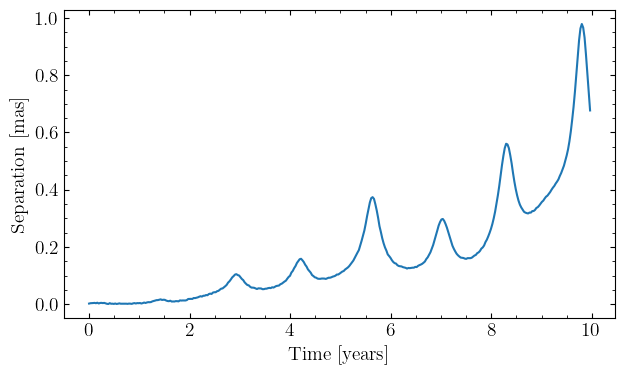

In [ ]:
fig, ax = plt.subplots()
ax.plot(
    (jnp.arange(0, 365 * 10, 10) * u.day).to(u.year),
    (jorbit_eph.separation(horizons_eph)).to(u.mas),
)
ax.set(xlabel="Time [years]", ylabel="Separation [mas]")

For this particle at least, the agreement between jorbit and Horizons is well under 1 mas for most of a decade.

For a not strictly scientific (but hopefully qualitatively assuring) test, we can repeat this whole procedure for a handful of other objects. We'll select them by randomly drawing numbered objects according to their IDs:

In [5]:
np.random.seed(42)
particle_ids = np.random.randint(0, 700_000, size=50)

times = Time("2025-01-01") + jnp.arange(0, 365 * 10, 10) * u.day

seps = np.zeros((len(particle_ids), len(times)))
for i, p_id in tqdm(enumerate(particle_ids)):
    p = Particle.from_horizons(name=str(p_id), time=Time("2025-01-01"))
    jorbit_eph = p.ephemeris(times=times, observer="kitt peak")

    data = horizons_bulk_astrometry_query(
        target=str(p_id), center="695@399", times=times
    )
    horizons_eph = SkyCoord(
        ra=data["RA"], dec=data["DEC"], unit=(u.deg, u.deg), obstime=times
    )
    separation = jorbit_eph.separation(horizons_eph)
    seps[i] = separation.to(u.mas).value

50it [03:25,  4.11s/it]


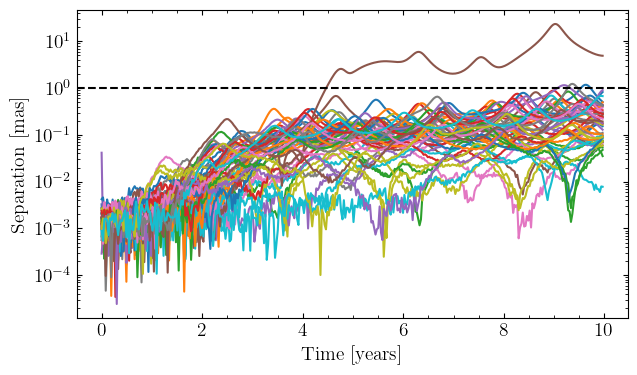

In [ ]:
fig, ax = plt.subplots()
ax.plot((jnp.arange(0, 365 * 10, 10) * u.day).to(u.year), seps.T)
ax.axhline(1, color="k", ls="--", label="1 mas")
ax.set(yscale="log", xlabel="Time [years]", ylabel="Separation [mas]")

Thankfully it looks like (274301) Wikipedia wasn't just a lucky guess and that most of these objects are also in good agreement with Horizons. As a rule of thumb, within a ~year or so the agreement is usually within 0.1 mas, and within a decade it's usually within 1 mas.

However, there is that one weird outlier that's off by ~20 mas. Let's take a closer look at that one, and use `integrate` to look at its actual position over time:

In [10]:
worst_idx = np.where(seps == seps.max())[0][0]
print(f"Worst offender: ({particle_ids[worst_idx]})")

p = Particle.from_horizons(name=str(particle_ids[worst_idx]), time=Time("2025-01-01"))
jorbit_eph = p.ephemeris(times=times, observer="kitt peak")

x, v = p.integrate(times)

Worst offender: (452366)


Let's compare its position to that of the known massive perturbers:

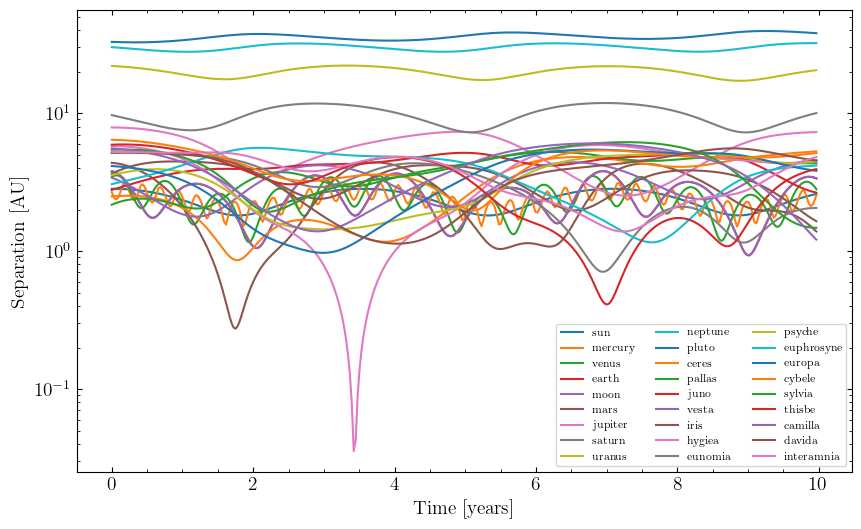

In [ ]:
eph = Ephemeris(ssos="default solar system")
solar_system_state = eph.state(times)

dists = {}
for obj in solar_system_state.keys():
    dists[obj] = np.linalg.norm(solar_system_state[obj]["x"].to(u.au).value - x, axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
for obj, dist in dists.items():
    ax.plot((jnp.arange(0, 365 * 10, 10) * u.day).to(u.year), dist, label=obj)
ax.legend(ncols=3, fontsize=8)
ax.set(yscale="log", xlabel="Time [years]", ylabel="Separation [AU]")

This shows that this object has a relatively close encounter with *something*, but with this messy plot it's hard to say what. Digging deeper, we can tell it's:

In [ ]:
stacked_dists = np.stack(list(dists.values()), axis=0)
closest_approaches = np.min(stacked_dists, axis=1)
closest_approach_idx = np.argmin(closest_approaches)
closest_approach_obj = list(dists.keys())[closest_approach_idx]
print(f"Closest approach is to {closest_approach_obj.upper()}")
print(
    f"on this coarse time grid, the closest approach occurs at {times[np.argmin(stacked_dists[closest_approach_idx])].iso}"
)
print(f"at a distance of {closest_approaches[closest_approach_idx]:.2e} AU")

Closest approach is to HYGIEA
on this coarse time grid, the closest approach occurs at 2028-06-04 00:00:00.000
at a distance of 3.56e-02 AU


Let's do a finer integration around now to see the result of the flyby more clearly:

In [ ]:
p = Particle.from_horizons(name="452366", time=Time("2028-01-01"))
times = Time("2028-01-01") + jnp.arange(0, 365 * 2, 0.333) * u.day

jorbit_eph = p.ephemeris(times=times, observer="kitt peak")

_data = horizons_bulk_astrometry_query(target="452366", center="695@399", times=times)
horizons_eph = SkyCoord(
    ra=_data["RA"], dec=_data["DEC"], unit=(u.deg, u.deg), obstime=times
)

x, v = p.integrate(times)

hygiea_state = eph.state(times)["hygiea"]["x"].to(u.au).value

Closest approach to Hygiea is 2.88e-02 AU
Closest approach to Hygiea occurs at 2028-06-07 20:11:02.400


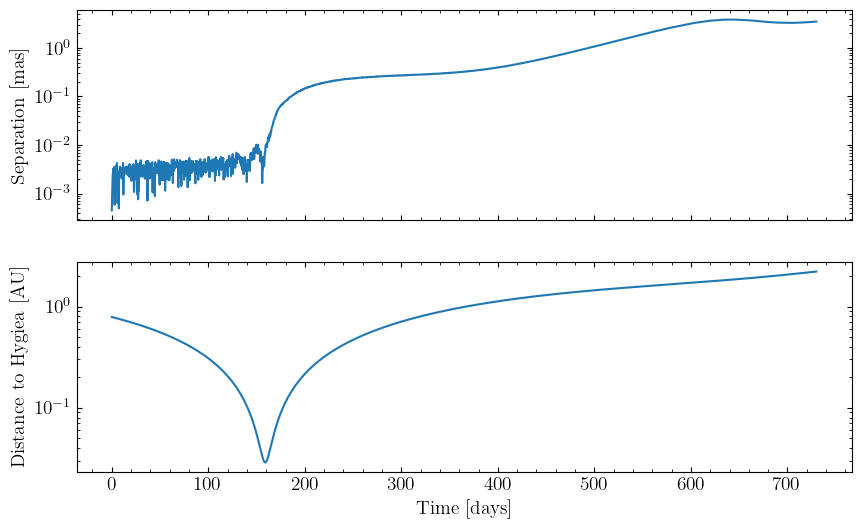

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6), nrows=2, sharex=True)
ax[0].plot(
    (times - Time("2028-01-01")).to(u.day),
    (jorbit_eph.separation(horizons_eph)).to(u.mas),
)
ax[0].set(ylabel="Separation [mas]", yscale="log")

ax[1].plot(
    (times - Time("2028-01-01")).to(u.day), np.linalg.norm(hygiea_state - x, axis=1)
)
ax[1].set(yscale="log", xlabel="Time [days]", ylabel="Distance to Hygiea [AU]")

print(
    f"Closest approach to Hygiea is {np.min(np.linalg.norm(hygiea_state - x, axis=1)):.2e} AU"
)
print(
    f"Closest approach to Hygiea occurs at {times[np.argmin(np.linalg.norm(hygiea_state - x, axis=1))].iso}"
)

We can clearly see the affects of the flyby: when (452366) gets within just a few hundredths of an AU of (10) Hygeia (which according to Wikipedia has a diameter of 433 km), our predicted positions begin to diverge.

Earlier versions of `jorbit` (pre v1.3.0, May 2026) did not see this discrepancy: it agreed much better with Horizons even including the flyby. This is because we now use `interpolate=True` by default when constructing a `Particle`'s ephemeris, which allows the integrator to take larger steps via the "PRS23" step-size controller. This has the benefit of speeding up integrations, but can in dynamically intense situations like this lead to slightly less accurate results (see the example notebooks about the flyby of (99942) Apophis for a more extreme example of this, and the "step_sizes" notebook in the repo for a discussion on the impact of the step-size controller).

If we instead use `interpolate=False`, we get much better agreement:

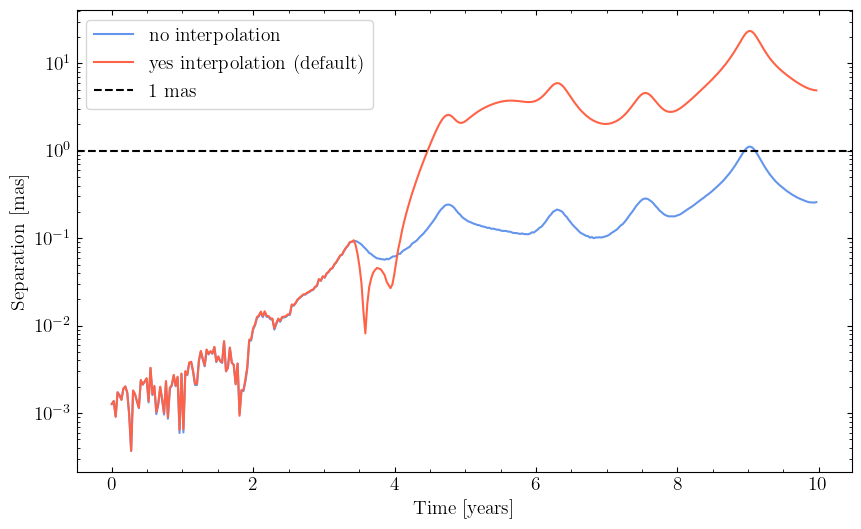

In [29]:
times = Time("2025-01-01") + jnp.arange(0, 365 * 10, 10) * u.day

p = Particle.from_horizons(name="452366", time=Time("2025-01-01"))
jorbit_eph_no_interp = p.ephemeris(times=times, observer="kitt peak", interpolate=False)
jorbit_eph = p.ephemeris(times=times, observer="kitt peak", interpolate=True)

_data = horizons_bulk_astrometry_query(target="452366", center="695@399", times=times)
horizons_eph = SkyCoord(
    ra=_data["RA"], dec=_data["DEC"], unit=(u.deg, u.deg), obstime=times
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(
    (jnp.arange(0, 365 * 10, 10) * u.day).to(u.year),
    (jorbit_eph_no_interp.separation(horizons_eph)).to(u.mas),
    color="cornflowerblue",
    label="no interpolation",
)
ax.plot(
    (jnp.arange(0, 365 * 10, 10) * u.day).to(u.year),
    (jorbit_eph.separation(horizons_eph)).to(u.mas),
    color="tomato",
    label="yes interpolation (default)",
)
ax.set(yscale="log", ylabel="Separation [mas]", xlabel="Time [years]")
ax.axhline(1, color="k", ls="--", label="1 mas")
ax.legend()